# A Simulation of Solutions to the Schrodinger Equation
This project is meant to be a useful aid in visualizing the solutions of the time-dependant Schrodinger equation in basic cases. It is also meant to showcase the mathematics behind solving the equation, using the Crank-Nicolson finite-difference method, from a first-year Physics undergraduate's perspective.

The equation in the 1-D case:
$$\frac{-\hbar ^2}{2m} \frac{\partial ^2}{\partial x^2} \Psi +U(x,t) \Psi =i\hbar \frac{\partial}{\partial t}\Psi$$

This is a second-degree PDE, which is difficult to solve analytically.
Instead, we will be solving this numerically. The Crank-Nicolson method is a method to solve such PDEs numerically, which we will be using to simulate a variety of simple 1D problems (and one 3D problem).

## The Crank-Nicolson Method
In our case of $\Psi (x,t)$, the idea is to numerically solve the equation (finding the numerical value of $\Psi$ for some given $x$ and $t$). Then, assuming $\Psi$ is smooth, we interpolate between these known points.

Let's say our domain of interest is rectangular,  $x \in [x_0,x_0+w]$, and $t \in [0, t_f]$.
We subdivide these domains into $S_x$ and $S_t$ equal subintervals of length $L_x$ and $L_t$ respectively, and designate $\Psi_{(j,k)}$ as the value of $\Psi$ at $(x,t) = (x + j L_x, k L_t)$. That is, $(j,k)$ is the index on the "grid" created by subdividing the domain:

<IMAGE GOES HERE WHEN I GET AROUND TO UPLOADING IT>

We can then create expressions to approximate the relevant partial derivatives of $\Psi$ at every $(j,k)$. Note that we actually center the difference expressions around the midpoints of each $t$-interval:
<UPDATE THESE FOR CENTERING AROUND MIDPOINTS>
$$\Psi = \frac{\Psi_{(j,k)} + \Psi_{(j,k+1)}}{2}$$
$$\frac{\partial \Psi}{\partial x} = \frac{\Psi_{(j + 1, k + 1)} - \Psi_{(j - 1,k + 1)} + \Psi_{(j + 1, k)} - \Psi_{(j,k)}}{4L_x}$$
$$\frac{\partial ^2 \Psi}{\partial x^2} = \frac{\Psi_{(j + 1, k+1)} - 2\Psi_{(j, k+1)} + \Psi_{(j-1,k+1)} + \Psi_{(j + 1, k)} - 2\Psi_{(j, k)} + \Psi_{(j-1,k)}}{2(L_x)^2}$$
$$\frac{\partial}{\partial t} = \frac{\Psi_{(j,k+1)} - \Psi_{(j,k)}}{L_t}$$

If we plug these back into our equation, then move the $k$-terms to one side and the $k+1$ terms to the other, we can re-arrange it as a linear system $Ax=B$ where $B$ has entries of the side of the equation dependant on $\Psi (\cdot,k)$, $x$ is a vector with entries $\Psi(\cdot, k+1)$ and $A$ has the coefficients of $\Psi(\cdot, k+1), \Psi(\cdot, k)$, and $\Psi(\cdot, k-1.)$ Then, we set appropriate boundary conditions, and can solve each successive time state based on the state of the previous state.

First we simulate the particle in a box. This simply has $U(x,t) = 0, \Psi = 0$ at $x = 0$ and $x = L$.

## The Particle In A Box

We start with our equation:
$$\frac{-\hbar ^2}{2m} \frac{\partial ^2}{\partial x^2} \Psi =i\hbar \frac{\partial}{\partial t}\Psi$$
Plugging in our derivatives:
$$\frac{-\hbar ^2}{2m} \frac{\Psi_{(j + 1, k+1)} - 2\Psi_{(j, k+1)} + \Psi_{(j-1,k+1)} + \Psi_{(j + 1, k)} - 2\Psi_{(j, k)} + \Psi_{(j-1,k)}}{2(L_x)^2} =i\hbar \frac{\Psi_{(j,k+1)} - \Psi_{(j,k)}}{L_t}$$
Moving the $k$ terms to the left and $k+1$ to the right:
$$\frac{-\hbar ^2}{2m} \frac{\Psi_{(j + 1, k)} - 2\Psi_{(j, k)} + \Psi_{(j-1,k)}}{2(L_x)^2} + i\hbar \frac{\Psi_{(j,k)}}{L_t} = \frac{\hbar ^2}{2m} \frac{\Psi_{(j + 1, k+1)} - 2\Psi_{(j, k+1)} + \Psi_{(j-1,k+1)} }{2(L_x)^2} + i\hbar \frac{\Psi_{(j,k+1)}}{L_t}$$
Grouping each side by $j$, $j+1$, and $j-1$:


$$\frac{-\hbar ^2}{2m} \frac{\Psi_{(j + 1, k)}}{2(L_x)^2} + \frac{-\hbar ^2}{2m} \frac{\Psi_{(j - 1, k)}}{2(L_x)^2} + (\frac{i\hbar}{L_t} + \frac{2\hbar^2}{2m*2(L_x)^2})\Psi_{(j,k)} = \frac{\hbar ^2}{2m} \frac{\Psi_{(j + 1, k+1)}}{2(L_x)^2} + \frac{\hbar ^2}{2m} \frac{\Psi_{(j - 1, k+1)}}{2(L_x)^2} + (\frac{i\hbar}{L_t} + \frac{-2\hbar^2}{2m*2(L_x)^2})\Psi_{(j,k+1)}$$

Now multiplying by $4mL_x^2L_t$:
$$-\hbar^2L_t\Psi_{(j + 1, k)} + -\hbar^2L_t\Psi_{(j - 1, k)} + (4i\hbar mL_x^2 + 2\hbar^2L_t)\Psi_{(j,k)} = \hbar^2L_t\Psi_{(j + 1, k+1)/} + \hbar^2L_t\Psi_{(j - 1, k+1)} + (4i\hbar mL_x^2 - 2\hbar^2L_t)\Psi_{(j,k+1)}$$


Let's designate the entire left side as $D_{(j,k)}$.
Then on the right, let
$$A_j = \hbar^2L_t$$
$$B_j = (4i\hbar mL_x^2 - 2\hbar^2L_t)$$
$$C_j = \hbar^2L_t$$

For some value of $D_j$ at time stepping $k$, it is equal to $A_j\Psi_{(j-1,k+1)} + B_j\Psi_{(j,k+1)} + C_j\Psi_{(j+1,k+1)}$

We can then represent this as a linear system and solve for each $\Psi_{(\cdot,k+1)}$ based on known $D_{(\cdot,k)}$.

Our stationary state is given by $\Psi = \sqrt{\frac{2}{L}}\sin{(\frac{\pi nx}{L})}$

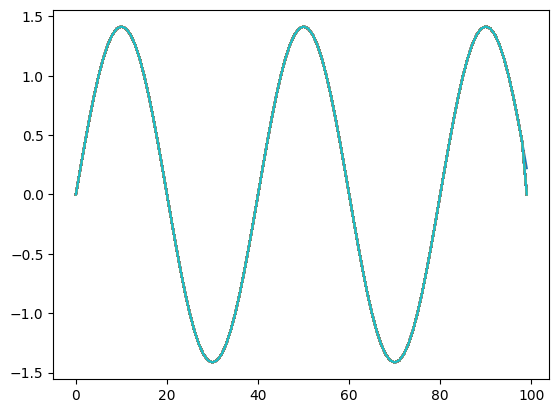

In [29]:
import matplotlib.pyplot as plt
import numpy as np
disp_m = 500 #this is mass in KeV/c^2
m = disp_m * 1000 #this is eV/c^2
HBAR = 6.582119569E-6 #this is 1e10 greater than its actual value in eV/s, but I need to scale everything up so we stay within FP precision
l = 1 #this is in nm
U = 0 #this is potential, probably needs to be turned into a matrix
Lt = 1 #this is in nanoseconds, and is the stepping for time
Lx = l/100 #this is the granularity of our finite-difference stepping in x
#coefficients of the matrix
Ai = (np.power(HBAR,2))/m * Lt
Bi = (-2*np.power(HBAR,2)/(m)) - (2*(np.power(Lx,2))*Lt*U) + (4*np.power(Lx,2)*1j*HBAR)
Bl = (2*np.power(HBAR,2)/(m)) + (2*(np.power(Lx,2))*Lt*U) + (4*np.power(Lx,2)*1j*HBAR) #this one is for Di
Ci = (np.power(HBAR,2))/m * Lt
n = 5 #just for the stationary state for now...
current_state = [] #holds all the psi values currently known
DArr = [] #holds the rhs of the equation
TArr = [] #linear transformation to go from each state
#We assume a sinusoidal form of psi initially
def init_psi_sinusoidal():
    for i in range (0, 100):
        current_state.append(np.sqrt(2/l) * np.sin(n*np.pi*(Lx*i)/l))
        DArr.append(-1)
        temp = []
        for j in range (0, 100):
            match i-j:
                case -1:
                    temp.append(Ci)
                case 0:
                    temp.append(Bi)
                case 1:
                    temp.append(Ai)
                case _:
                    temp.append(0)
        TArr.append(temp)
    #boundary conditions
    TArr[0][0] = 1
    TArr[0][1] = 0
    TArr[99][98] = 0
    TArr[99][99] = 1
init_psi_sinusoidal() #yes, I did make a method I'm calling once and only once. There will be a button-y GUI eventually where this comes in handy.
CS = np.array(current_state)
DA = np.array(DArr, complex)
TA = np.array(TArr)
plt.plot(CS)

#These coefficients are largely the same for calculated Di, but some signs are flipped
def set_bounds():
    DA[0] = 0
    DA[99] = 0
def calc_Di():
    set_bounds()
    for i in range (1,99):
        DA[i] = (-Ai * CS[i-1]) + (Bl * CS[i]) - (Ci * CS[i+1])
for k in range (1,100): #as we can see, nothing changes, which is really good and means I didn't mess up
    calc_Di()
    NS = np.linalg.solve(TA,DA) #we will have some kind of interpretation, at some point.
    plt.plot(NS)
    CS = NS
